## Reinforcement Learning Strategy for Algorithmic Trading

In [3]:
# Importing the libraries
from sentiment_lib import *

# Parameters
time_window = 60
ticker = "KO"
model = 'rppo'
base_path = "normal"

In [4]:
# Importing the datasets
train_df = pd.read_csv(f"rl_dfs/train/{ticker}.csv", index_col=0)
train_df.index = pd.to_datetime(train_df.index)

test_df = pd.read_csv(f"rl_dfs/test/{ticker}.csv", index_col=0)
test_df.index = pd.to_datetime(test_df.index)

# Number of steps for each iteration
num_of_steps = train_df.shape[0] - time_window
print(f"Number of steps: {num_of_steps}")

Number of steps: 62444


In [5]:
# Parameters for training environment
train_kwargs = {
    "data": train_df,
    "ticker":ticker, 
    "time_window":time_window,
    "trade_cost":0,
    "reward_logic":"log_position",
    "reward_scale":1E4,
    "only_long":False,
    "verbose":False
}

# Parameters for testing environment
test_kwargs = {
    "data": test_df,
    "ticker":ticker, 
    "time_window":time_window,
    "trade_cost":0,
    "reward_logic":"log_position",
    "reward_scale":1E4,
    "only_long":False,
    "verbose":False
}

# Model parameters
model_parameters = {
    'n_steps': 60,
    'gamma': 0.995,
    'ent_coef': 0.005,
    'learning_rate': 0.0003,
    "batch_size": 60
}

# Policy parameters
policy_kwargs = dict(
    net_arch=[dict(vf=[128, 128, 128], pi=[128, 128])],
    lstm_hidden_size=256,
    n_lstm_layers=2
)



In [6]:
# Creating the pipeline and its processes
mt = MultiProcessingPipeline(ticker=ticker,
                             train_kwargs=train_kwargs, 
                             test_kwargs=test_kwargs,
                             n_process=3,
                             model=model,
                             base_path=base_path)

now = datetime.now()
mt.create_process_conditions(model_parameters, 
                             policy_parameters=policy_kwargs,
                             policy="MultiInputLstmPolicy", 
                             total_timesteps = num_of_steps*3)


Creating process  0



Creating process  1

Creating process  2


In [7]:
today = now.strftime("%Y%m%d")
now_str = f"{now.hour}h{now.minute}"
log_paths = os.path.join(RESULTS_DIR, base_path, ticker,today, now_str, model)
tensorboard_command = f"tensorboard --logdir {log_paths} --port 6006"

print("source .venv/bin/activate")
print(tensorboard_command)

source .venv/bin/activate
tensorboard --logdir results/normal/KO/20250307/8h9/rppo --port 6006


In [8]:
# Training and testing the model
start = datetime.now()
mt.multi_tasking()

print(f"Training and testing time: {datetime.now() - start}")

Successfully load model results/normal/KO/20250307/08h09/rppo_1/agent_rppo.zip
Successfully load model results/normal/KO/20250307/08h09/rppo_2/agent_rppo.zip
Successfully load model results/normal/KO/20250307/08h09/rppo_0/agent_rppo.zip
Training and testing time: 9:09:36.226668



Results of process 1

==== Final Metrics ====
Total Return : 1.01
Sharpe Ratio : 0.00
Max Drawdown : 0.06
Hit Ratio : 0.49


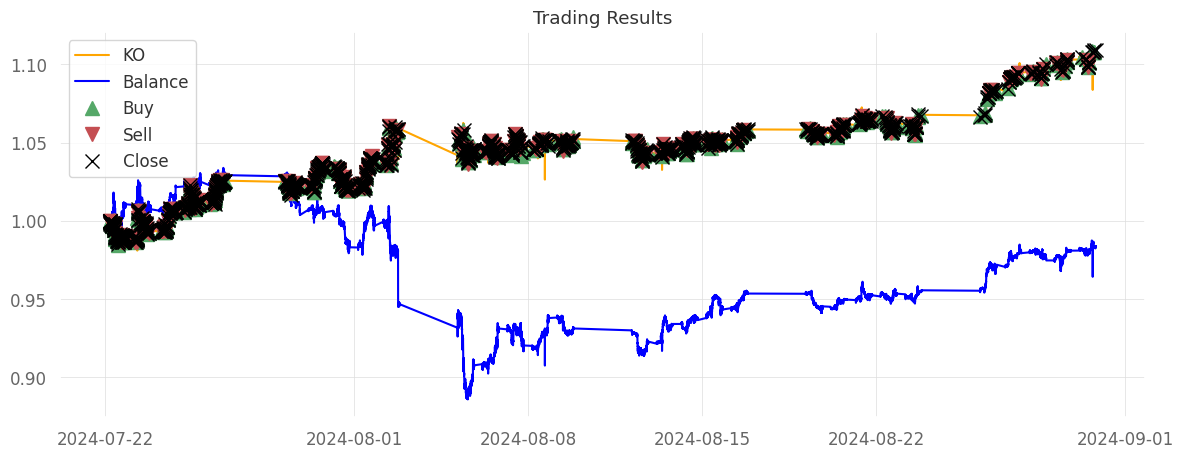


Results of process 2

==== Final Metrics ====
Total Return : 1.44
Sharpe Ratio : nan
Max Drawdown : 0.00
Hit Ratio : 1.00
'DataFrame' object has no attribute 'arrow_down'

Results of process 0

==== Final Metrics ====
Total Return : 1.10
Sharpe Ratio : 0.16
Max Drawdown : 0.02
Hit Ratio : 0.57


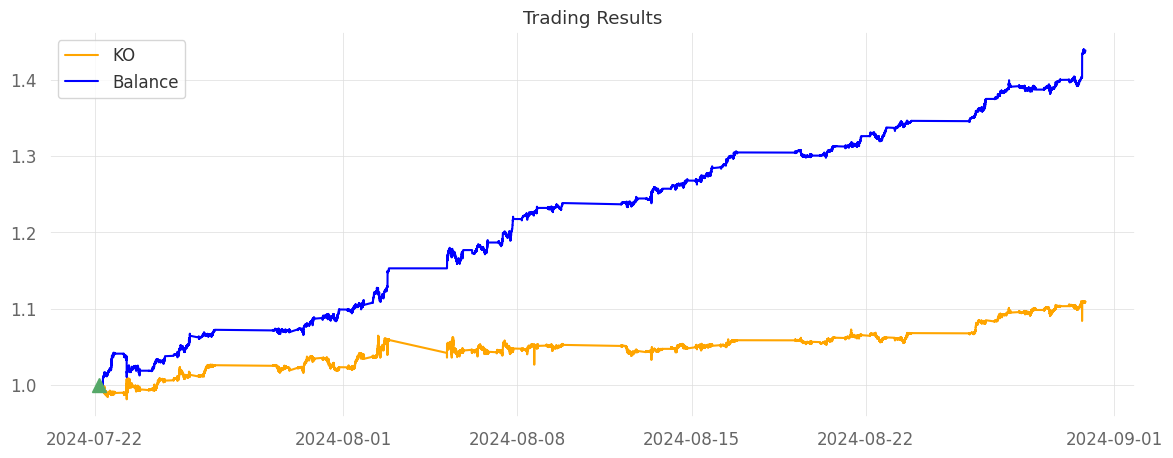

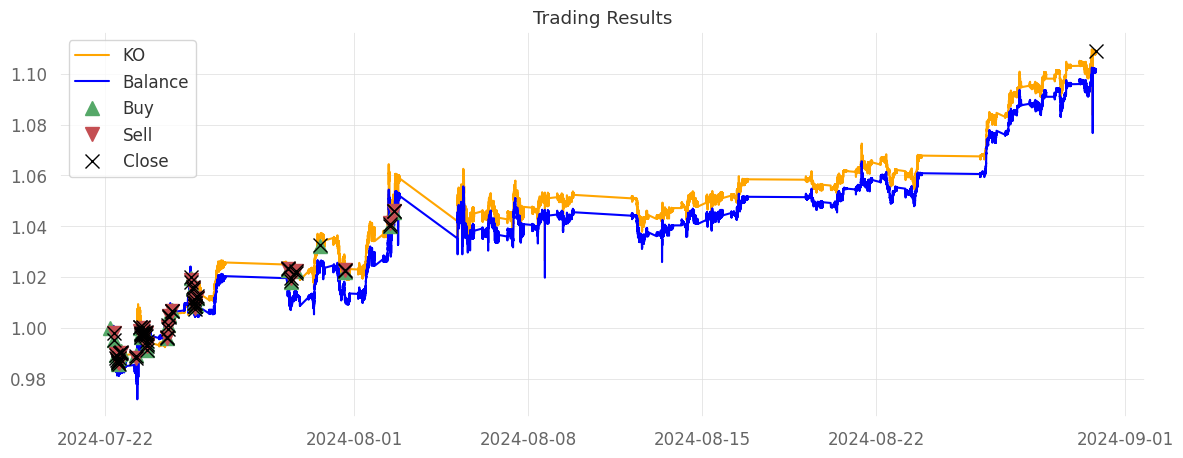

In [9]:
# Getting the results
mt.get_results()